# Definición de funciones (importadas de utils.py)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import math
from typing import Callable, Generator

In [ ]:
def iterate(R: Callable[[complex], complex], z0: complex, max_iter: int):
    """
    Generates the orbit of z0 under the rational function R.
    Yields successive values until max_iter is reached or z escapes to infinity.
    """
    z = z0
    zn = [z0]
    
    for _ in range(max_iter):
        try:
            z = R(z)
            
            # Check for standard float infinity or NaN
            if math.isinf(z.real) or math.isnan(z.real):
                break
                
            zn.append(z)
            
        except (ZeroDivisionError, OverflowError):
            # Hit a pole exactly, or the float overflowed
            break
    
    return zn

In [4]:
def plot_sequence_dark(zn, center: complex, zoom):
    zn = np.array(zn)
    
    plt.figure(figsize=(10, 10))
    plt.style.use('dark_background')

    # 1. Use a brighter colormap like 'plasma', 'spring', or 'autumn'
    # 'plasma' is great because it goes from bright purple to yellow
    colors = np.linspace(0, 1, len(zn))
    
    # 2. Add a very thin line connecting the points so you can see the 'flow'
    plt.plot(zn.real, zn.imag, color='white', linewidth=0.5, alpha=0.3)

    # 3. Increase size (s) and remove transparency (alpha)
    plt.scatter(zn.real, zn.imag, c=colors, cmap='viridis', s=30, alpha=1.0, edgecolors='none')

    # Highlight start and end with distinct colors
    plt.scatter(zn.real[0], zn.imag[0], color='white', s=50, label='Start (z0)', zorder=5)
    plt.scatter(zn.real[-1], zn.imag[-1], color='red', s=50, label='End', zorder=5)

    plt.axhline(0, color='white', linewidth=0.5, alpha=0.3)
    plt.axvline(0, color='white', linewidth=0.5, alpha=0.3)
    
    # Labels and Grid
    plt.title(f"$z^2$ iterations (Zoom: {zoom})")
    plt.legend(scatterpoints=1)
    plt.grid(alpha=0.1)

    # --- Zoom Settings ---
    plt.xlim(center.real - zoom, center.real + zoom)
    plt.ylim(center.imag - zoom, center.imag + zoom)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.show()

# Ejemplo del libro ($z \to z^2$)

## Puntos fijos

Encontramos los puntos fijos:

In [5]:
z = sp.Symbol('z')
fixed_points_equation = sp.Eq(z**2, z)
fixed_points = sp.solve(fixed_points_equation, z)
print(fixed_points)



[0, 1]


Ahora analizamos su comportamiento. Notar que $\infty$ también es un punto fijo.

In [6]:
z = sp.Symbol('z')
R = z**2
R_prime = R.diff(z)
print(R_prime)


2*z


$R'(z) = 2x$

In [7]:
R_prime.subs(z, 0)

0

Cómo $|(R'(0))| = 0 \lt 1 $, $0$ es un punto fijo atractor.

In [8]:
R_prime.subs(z, 1)

2

Cómo $|(R'(1))| = 2 \gt 1 $, $1$ es un punto fijo repulsor.

Analizando el caso de $\infty$ a mano, se puede ver que es atractor.

## Regiones de $\mathbb{C}_\infty$

Primero analizaremos las regiones que van a ser más fáciles, $C_1 = \{z : |z| \lt 1 \}$ y $C_2 = \{z : |z| \gt 1 \}$.

Si tenemos $z \in C_1$, es claro que $R^n(z) \to 0$.

In [9]:
def R(z):
    return z**2

In [10]:
r = np.random.uniform(0, 1)
theta = np.random.uniform(0, 2*np.pi)

z0 = r*np.exp(np.pi*theta*1j)

In [11]:
max_iter = 100
zn = iterate(R, z0, max_iter)

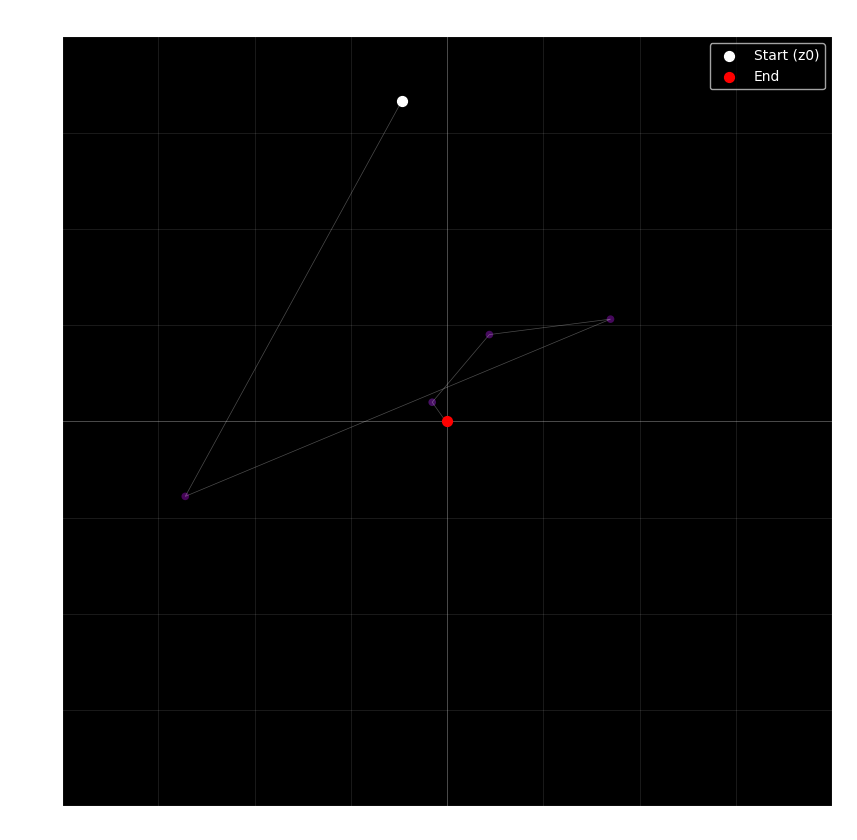

In [12]:
center = 0
zoom = 1
plot_sequence_dark(zn, center, zoom)

Si tenemos $z \in C_2$, es claro que $R^n(z) \to \infty$.

In [13]:
r = np.random.uniform(1, 10)
theta = np.random.uniform(0, 2*np.pi)

z0 = r*np.exp(np.pi*theta*1j)

In [14]:
max_iter = 10
zn = iterate(R, z0, max_iter)

C:\Users\abald\AppData\Local\Temp\ipykernel_23132\1802130496.py:2: RuntimeWarning: overflow encountered in scalar power
  return z**2
C:\Users\abald\AppData\Local\Temp\ipykernel_23132\1802130496.py:2: RuntimeWarning: invalid value encountered in scalar power
  return z**2


In [15]:
index = 1
for z in zn:
    print(index, ': ', np.abs(z))
    index += 1

1 :  7.496623673692096
2 :  56.1993665049608
3 :  3158.36879555891
4 :  9975293.448760238
5 :  99506479388878.9
6 :  9.901539440369381e+27
7 :  9.804048328919039e+55
8 :  9.61193636357802e+111
9 :  9.238932065747345e+223


Ahora vayamos con el caso interesante, $C = \{z : |z| = 1\}$. Notemos que como $1$ es un punto divergente, la única forma en la que $R^n(z) \to 1$ es si $\exists m$ tal que $R^m(z) = 1$, lo cual equivale a que $z = \exp\left(i \frac{2\pi r}{2^m}\right)$, donde $r$, $m \in \mathbb{N}$. Además, los puntos de esta forma son densos en $C$.

Sin embargo, todos los puntos que no sean de dicha forma (que también son densos en $C$) nunca convergerán en $1$ y tampoco saldrán de $C$. Parte de estos puntos serán puntos periódicos (puntos fijos de $R^n$ para algún $n \in \mathbb{N}$, es decir, $(2^n -1)$-th raíces de la unidad), que son también densos en $C$, y otra parte serán puntos que nunca formarán un ciclo pero tampoco convergerán (que también son densos en $C$), simplemente darán vueltas sin parar y sin nunca repetir un punto, pero siempre dentro de $C$.

Veamos ejemplos para todos estos casos.

Punto que converge a 1.

In [55]:
m = int(np.random.uniform(0, 11))
r = int(np.random.uniform(0, 2**m))

z0 = np.exp(2j*np.pi*r/(2**m))

In [56]:
max_iter = m
zn = iterate(R, z0, max_iter)

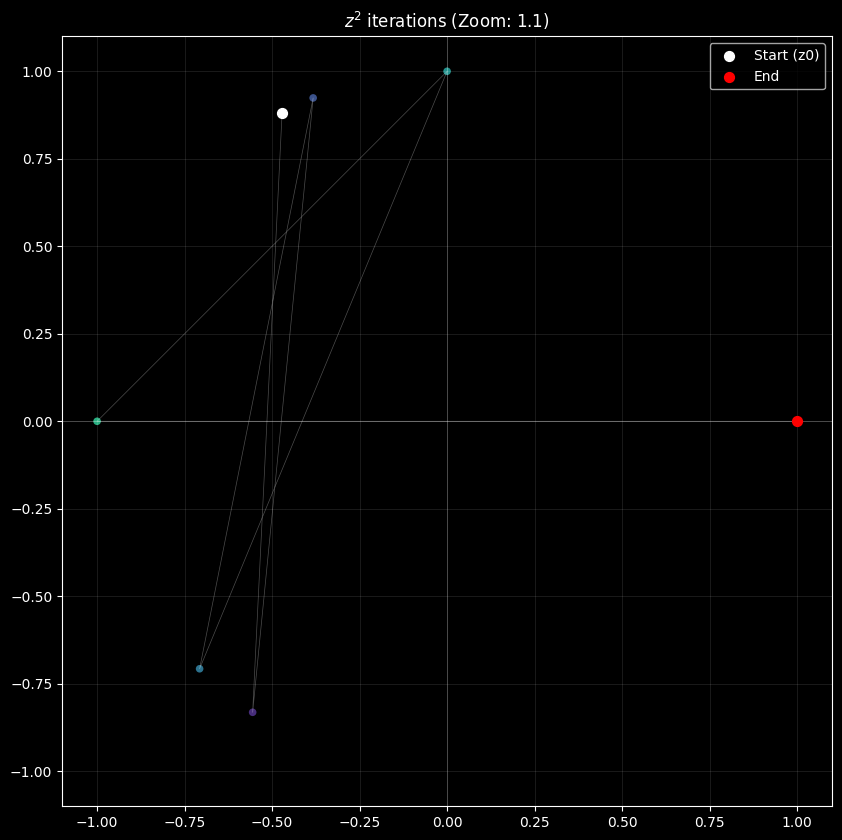

In [57]:
center = 0
zoom = 1.1
plot_sequence_dark(zn, center, zoom)

Punto cíclico.

In [19]:
n = int(np.random.uniform(0, 11))
r = int(np.random.uniform(0, 2**n - 1))

z0 = np.exp(2j*np.pi*r/(2**n - 1))

In [20]:
max_iter = n
zn = iterate(R, z0, max_iter)

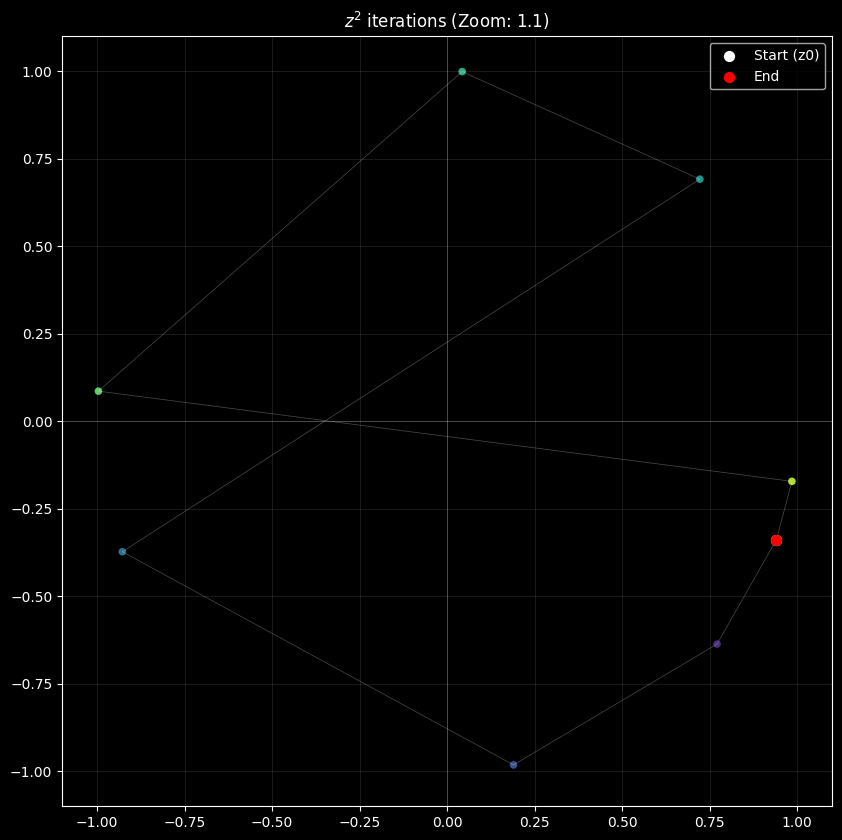

In [21]:
center = 0
zoom = 1.1
plot_sequence_dark(zn, center, zoom)

Punto no cíclico, no convergente. (eligo uno al azar, estadísticamente lo más probable es que sea no cíclico y no convergente)

In [22]:
theta = np.random.uniform(0, 2*np.pi)

z0 = np.exp(1j*theta)

In [23]:
max_iter = 40
zn = iterate(R, z0, max_iter)

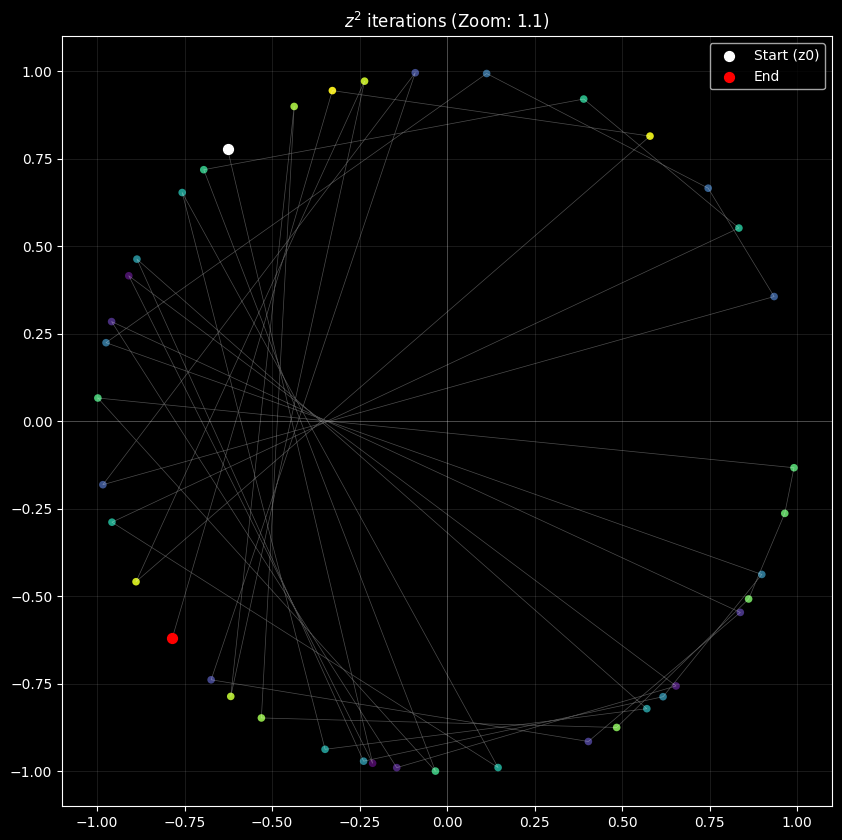

In [24]:
center = 0
zoom = 1.1
plot_sequence_dark(zn, center, zoom)

# Ejercicio 1

In [25]:
def R(z):
    return z**-2

Los puntos fijos son $\zeta_1 = 1$, $\zeta_2 = \exp\left(i\frac{2\pi}{3}\right)$, $\zeta_3 = \exp\left(i\frac{4\pi}{3}\right)$. Y son todos repulsores. El comportamiento en la circuferencia unidad centrada en $0$ es quedarse ahí. Fuera de este conjunto los puntos se van alejando cada vez más de la circunferencia unidad centrada en $0$ alternando entre estar dentro y fuera de esta. Es decir, se van acercando de manera alternante al $0$ y al $\infty$.

Punto no fijo en la circunferencia unidad centrada en $0$.

In [26]:
r = 1
theta = np.random.uniform()

z0 = r*np.exp(2j*np.pi*theta)

In [27]:
max_iter = 40
zn = iterate(R, z0, max_iter)

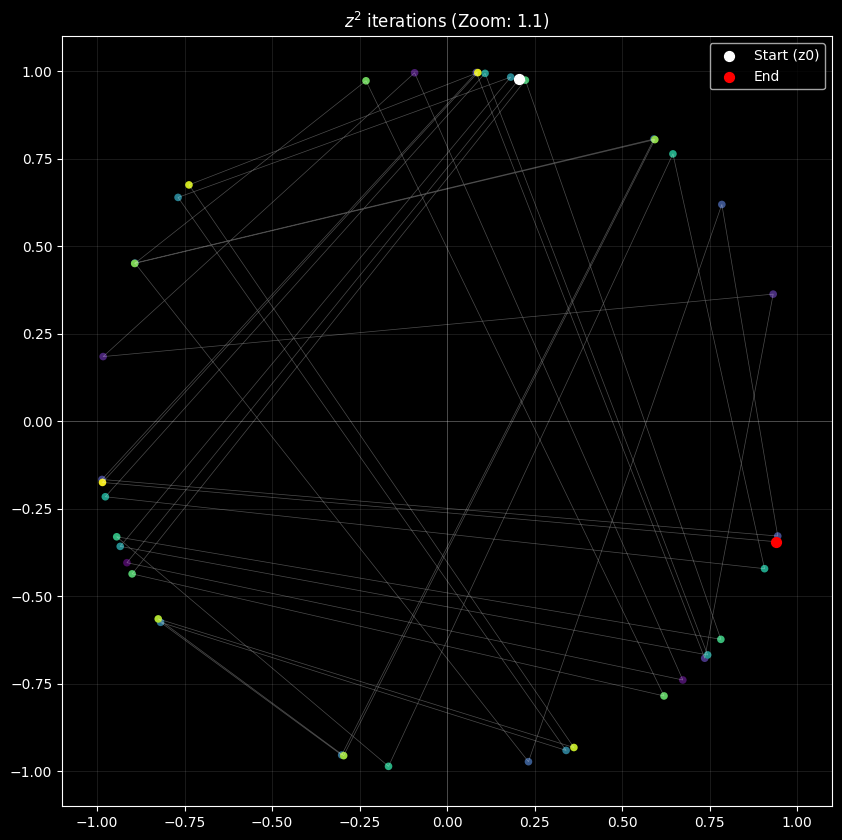

In [28]:
center = 0
zoom = 1.1
plot_sequence_dark(zn, center, zoom)

Punto fuera de la circunferencia unidad centrada en $0$.

In [29]:
r = np.random.uniform()
theta = np.random.uniform()

z0 = r*np.exp(2j*np.pi*theta)

In [30]:
max_iter = 10
zn = iterate(R, z0, max_iter)

C:\Users\abald\AppData\Local\Temp\ipykernel_23132\1893765185.py:2: RuntimeWarning: overflow encountered in scalar power
  return z**-2
C:\Users\abald\AppData\Local\Temp\ipykernel_23132\1893765185.py:2: RuntimeWarning: invalid value encountered in scalar power
  return z**-2


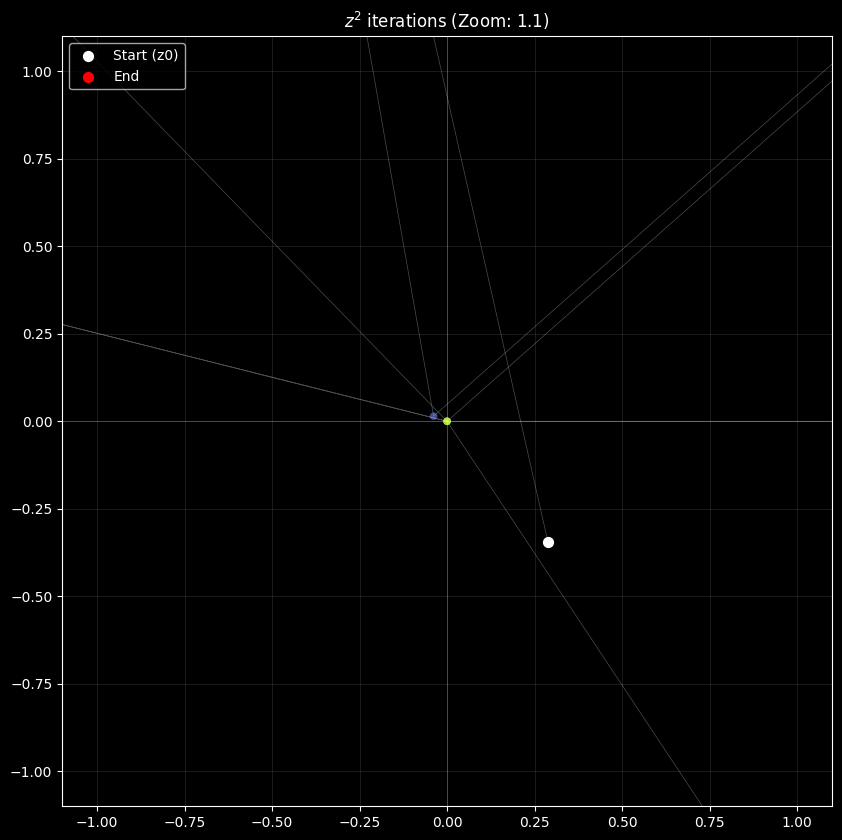

In [31]:
center = 0
zoom = 1.1
plot_sequence_dark(zn, center, zoom)

In [32]:
index = 1
for z in zn:
    print(index, ': ', abs(z))
    index += 1

1 :  0.4505936927862438
2 :  4.9252670519428525
3 :  0.041223079649793506
4 :  588.4629615020856
5 :  2.8877642383397417e-06
6 :  119915834008.28326
7 :  6.954196136982108e-23
8 :  2.0677885642929974e+44
9 :  2.3387712238437702e-89
10 :  1.8282034185428804e+177


Si analizamos las iteraciones pares vemos que cada vez son más grandes (porque hemos empezado dentro de la circunferencia, si empezaramos fuera serían cada vez más pequeñas).

In [33]:
index = 1
for z in zn:
    if index%2 == 0:
        print(index, ': ', abs(z))
    index += 1

2 :  4.9252670519428525
4 :  588.4629615020856
6 :  119915834008.28326
8 :  2.0677885642929974e+44
10 :  1.8282034185428804e+177


Si analizamos las iteraciones impares vemos que cada vez son más pequeñas (porque hemos empezado dentro de la circunferencia, si empezaramos fuera serían cada vez más grandes).

In [34]:
index = 1
for z in zn:
    if index%2 == 1:
        print(index, ': ', abs(z))
    index += 1

1 :  0.4505936927862438
3 :  0.041223079649793506
5 :  2.8877642383397417e-06
7 :  6.954196136982108e-23
9 :  2.3387712238437702e-89


# Ejercicio 4

In [58]:
def R(z):
    return z**2

Función para encontrar el $z_{-n}$:

In [59]:
def find_zn_negative(R, zeta: complex, z0: complex, n: int):
    theta_zeta = np.angle(zeta)
    theta0 = np.angle(z0)
    r0 = np.abs(z0)
    
    rn = r0 ** (1 / (2**n))
    
    k_exact = (theta_zeta * (2**n) - theta0) / (2 * np.pi)
    k_optimal = round(k_exact)
    
    theta_n = (theta0 + 2 * np.pi * k_optimal) / (2**n)
    
    return rn * np.exp(1j * theta_n)

Probemos para un $\zeta$ aleatorio en la circunferencia unidad y un $z_0$ aleatorio dentro de la circunferencia unidad a encontrar $z_{-10}$.

In [65]:
r = 1
theta = np.random.uniform()

zeta = r*np.exp(2j*np.pi*theta)

In [66]:
r = np.random.uniform(0.5, 1)
theta = np.random.uniform()

z0 = r*np.exp(complex(0, 2*np.pi*theta))

In [67]:
n = 10
zn_negative = find_zn_negative(R, zeta, z0, n)

In [75]:
print(abs(zn_negative - zeta))

0.0018114913683934127


Se puede ver que $z_{-10}$ está bastante cerca de $\zeta$.

Ahora pruebo a iterar para ver que efectivamente, de $z_{-10}$ se llega a $z_0$ en 10 iteraciones.

In [68]:
max_iter = n
zn = iterate(R, zn_negative, max_iter)

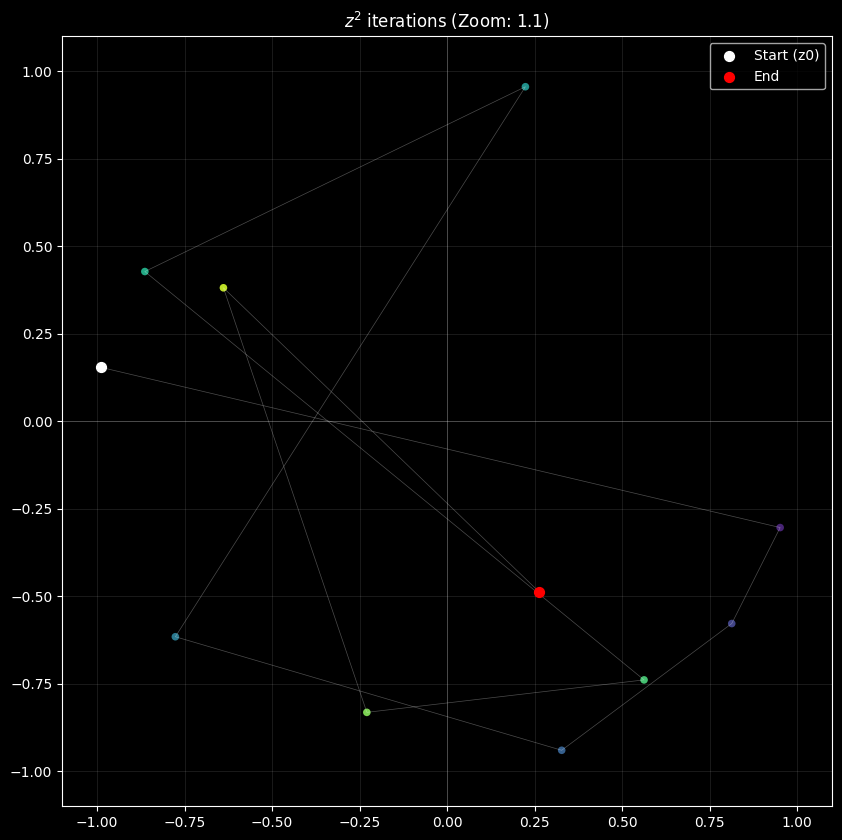

In [69]:
center = 0
zoom = 1.1
plot_sequence_dark(zn, center, zoom)

In [70]:
print(abs(z0), np.angle(z0))
print(abs(zn[-1]), np.angle(zn[-1]))

0.5538611892617935 -1.0761479951441022
0.5538611892617884 -1.0761479951446018


Si siguieramos iterando llegaríamos al 0.

In [72]:
max_iter = 2*n
zn = iterate(R, zn_negative, max_iter)

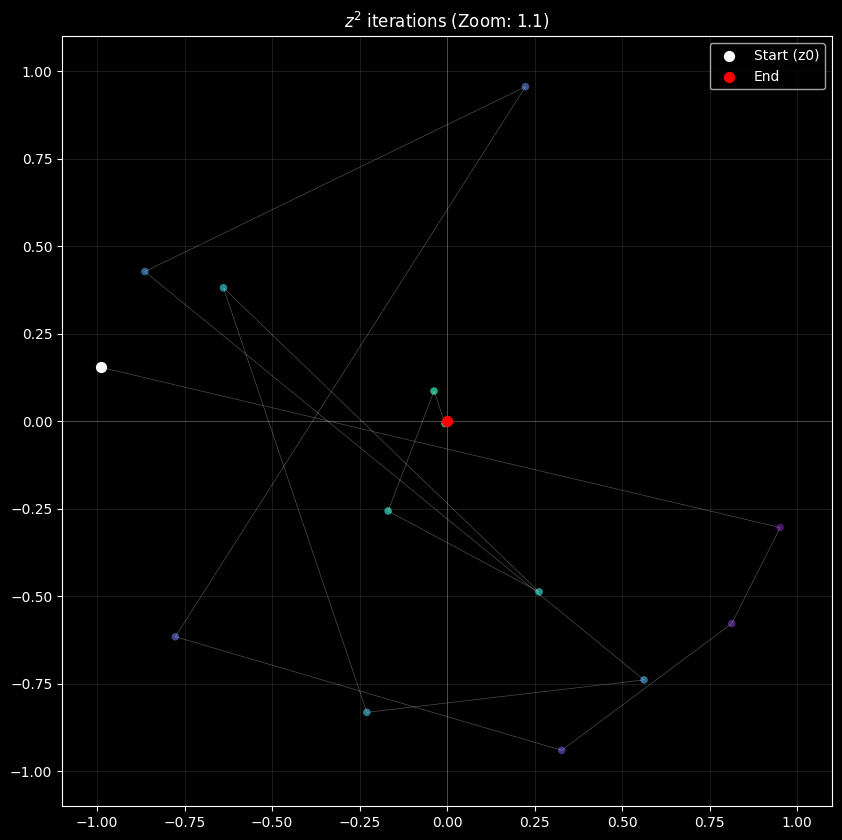

In [73]:
center = 0
zoom = 1.1
plot_sequence_dark(zn, center, zoom)

Ahora pruebo para un $z_0$ fuera de la circunferencia unidad.

In [76]:
r = 1
theta = np.random.uniform()

zeta = r*np.exp(2j*np.pi*theta)

In [77]:
r = np.random.uniform(1, 10)
theta = np.random.uniform()

z0 = r*np.exp(complex(0, 2*np.pi*theta))

In [78]:
n = 10
zn_negative = find_zn_negative(R, zeta, z0, n)

In [79]:
print(abs(zn_negative - zeta))

0.002045548417307855


Se puede ver que $z_{-10}$ está bastante cerca de $\zeta$.

Ahora pruebo a iterar para ver que efectivamente, de $z_{-10}$ se llega a $z_0$ en 10 iteraciones.

In [80]:
max_iter = n
zn = iterate(R, zn_negative, max_iter)

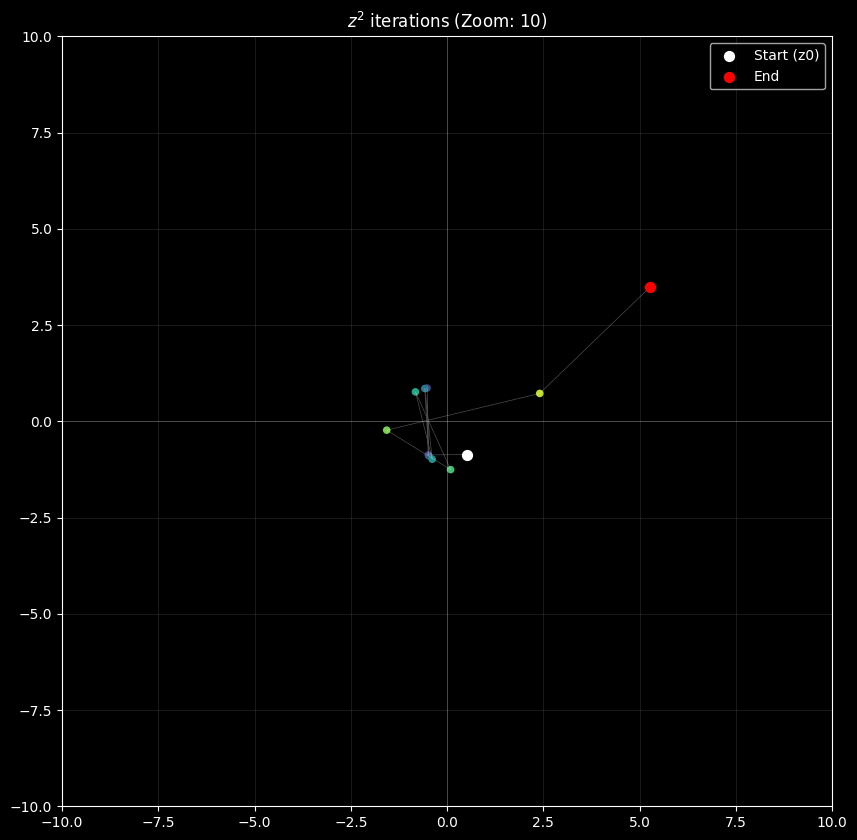

In [82]:
center = 0
zoom = 10
plot_sequence_dark(zn, center, zoom)

Si siguieramos iterando llegaríamos al $\infty$.

In [86]:
max_iter = n + 3
zn = iterate(R, zn_negative, max_iter)

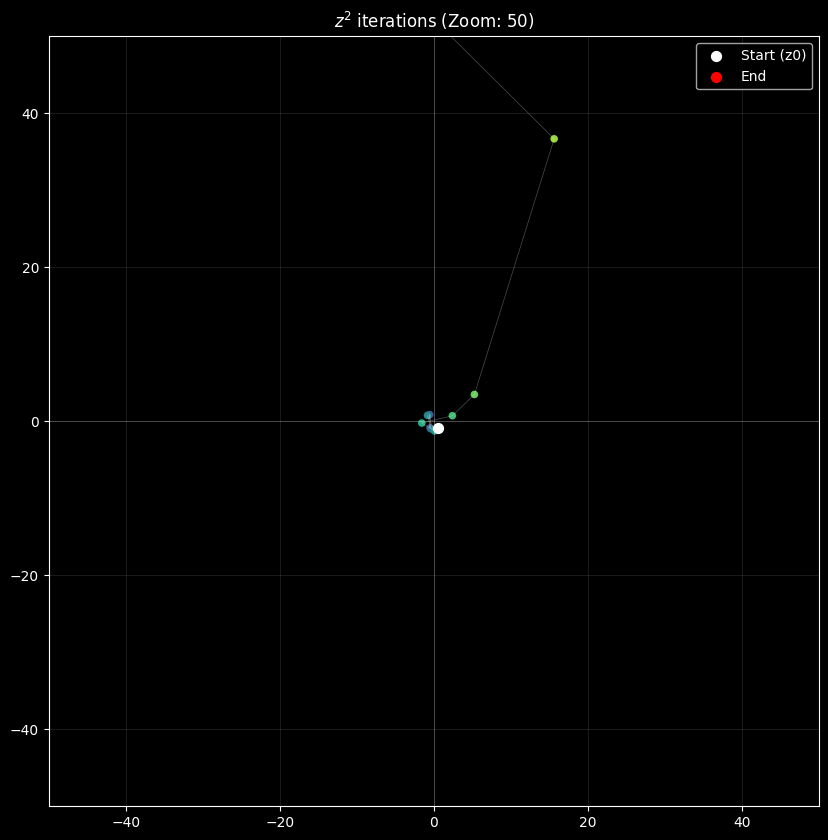

In [91]:
center = 0
zoom = 50
plot_sequence_dark(zn, center, zoom)